# Preprocessing — MAGIC Gamma Telescope Dataset

---
**Goal:** Prepare data for modeling:
1. Encode labels (g → 1, h → 0)
2. Split into train / test sets
3. Standardize features
4. Verify everything looks correct

## 1. Imports

In [1]:
import sys
sys.path.append('..')   # so we can import from src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import run_pipeline, FEATURES

sns.set_theme(style='whitegrid')
print('✅ Imports OK')

✅ Imports OK


## 2. Run Full Pipeline

In [2]:
X_train, X_test, y_train, y_test, scaler = run_pipeline('../data/magic04.data')

  MAGIC Telescope — Preprocessing Pipeline
✅ Data loaded: 19020 rows, 11 columns
✅ Labels encoded: Gamma (1) = 12332, Hadron (0) = 6688
✅ Train set: 15216 samples
✅ Test set:  3804 samples
   Class ratio in train — Gamma: 64.8%, Hadron: 35.2%
✅ Features standardized (mean=0, std=1)
   Example — fAlpha mean after scaling: 0.0000
✅ Scaler saved to: ../models/scaler.pkl

✅ Pipeline complete! Ready for modeling.


## 3. Verify Label Encoding

In [3]:
print('Label values in y_train:', y_train.unique())
print('\nClass distribution in train:')
print(y_train.value_counts().rename({1: 'Gamma (1)', 0: 'Hadron (0)'}))

print('\nClass distribution in test:')
print(y_test.value_counts().rename({1: 'Gamma (1)', 0: 'Hadron (0)'}))

Label values in y_train: [1 0]

Class distribution in train:
class
Gamma (1)     9866
Hadron (0)    5350
Name: count, dtype: int64

Class distribution in test:
class
Gamma (1)     2466
Hadron (0)    1338
Name: count, dtype: int64


## 4. Verify Stratification

The class ratio should be the same in train and test — this is what `stratify=y` does.

Gamma ratio in TRAIN: 0.6484 (64.8%)
Gamma ratio in TEST:  0.6483 (64.8%)
Difference: 0.0001 (should be very small ✅)


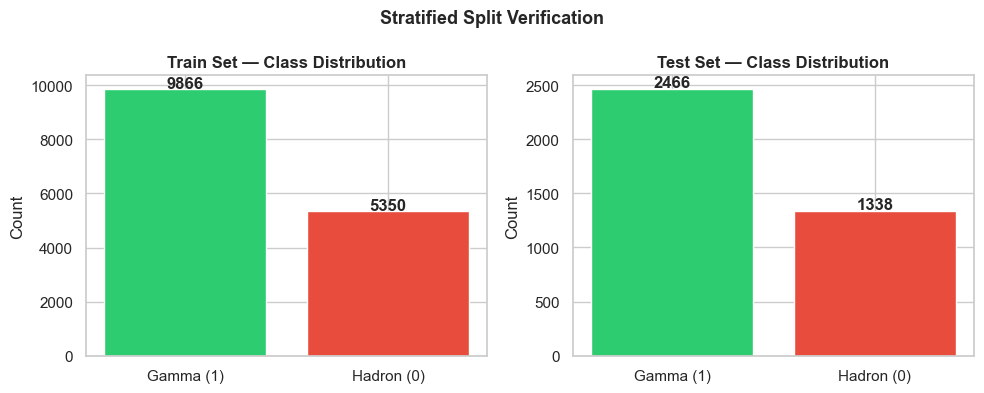

In [4]:
train_ratio = y_train.mean()
test_ratio  = y_test.mean()

print(f'Gamma ratio in TRAIN: {train_ratio:.4f} ({train_ratio:.1%})')
print(f'Gamma ratio in TEST:  {test_ratio:.4f} ({test_ratio:.1%})')
print(f'Difference: {abs(train_ratio - test_ratio):.4f} (should be very small ✅)')

# Visual
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y, title) in zip(axes, [(y_train, 'Train Set'), (y_test, 'Test Set')]):
    counts = y.value_counts()
    ax.bar(['Gamma (1)', 'Hadron (0)'], counts.values,
           color=['#2ecc71', '#e74c3c'], edgecolor='white')
    ax.set_title(f'{title} — Class Distribution', fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Stratified Split Verification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Verify Scaling

After StandardScaler: each feature should have **mean ≈ 0** and **std ≈ 1** in train set.

In [5]:
stats = pd.DataFrame({
    'Mean (train)': X_train.mean().round(4),
    'Std (train)':  X_train.std().round(4),
    'Mean (test)':  X_test.mean().round(4),
    'Std (test)':   X_test.std().round(4),
})

print('Feature statistics after StandardScaler:')
print(stats.to_string())
print('\n✅ Train mean ≈ 0, Train std ≈ 1 — scaling correct!')
print('   Test mean/std may differ slightly — this is expected and correct.')

Feature statistics after StandardScaler:
          Mean (train)  Std (train)  Mean (test)  Std (test)
fLength            0.0          1.0       0.0257      1.0198
fWidth            -0.0          1.0       0.0259      1.0301
fSize             -0.0          1.0       0.0219      1.0116
fConc             -0.0          1.0      -0.0163      0.9940
fConc1            -0.0          1.0      -0.0161      0.9924
fAsym              0.0          1.0       0.0018      1.0233
fM3Long            0.0          1.0       0.0118      1.0073
fM3Trans          -0.0          1.0       0.0159      1.0043
fAlpha             0.0          1.0      -0.0301      0.9837
fDist             -0.0          1.0       0.0156      1.0105

✅ Train mean ≈ 0, Train std ≈ 1 — scaling correct!
   Test mean/std may differ slightly — this is expected and correct.


## 6. Why Do We Scale?

Some of our features have very different ranges:
- `fAlpha` ranges 0–90 degrees  
- `fConc` ranges 0–1 (ratio)

Without scaling, algorithms like Logistic Regression or KNN would treat large-range features as more important. Scaling makes all features equally weighted at the start.

✅ Data loaded: 19020 rows, 11 columns
✅ Labels encoded: Gamma (1) = 12332, Hadron (0) = 6688


C:\Users\Kamila\AppData\Local\Temp\ipykernel_14928\2766728436.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X_raw[f].values for f in FEATURES], labels=FEATURES)
C:\Users\Kamila\AppData\Local\Temp\ipykernel_14928\2766728436.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_train[f].values for f in FEATURES], labels=FEATURES)


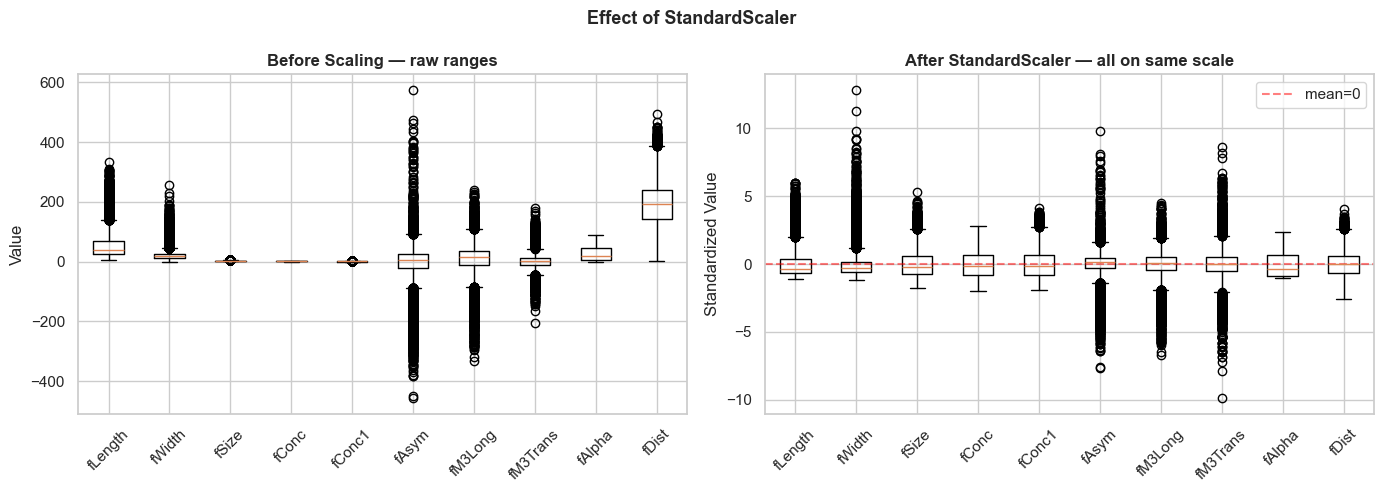

In [6]:
# Load raw data to compare before/after
from src.preprocessing import load_data, encode_labels, split_data, FEATURES

df_raw = encode_labels(load_data('../data/magic04.data'))
X_raw = df_raw[FEATURES]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].boxplot([X_raw[f].values for f in FEATURES], labels=FEATURES)
axes[0].set_title('Before Scaling — raw ranges', fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=45)

# After scaling
axes[1].boxplot([X_train[f].values for f in FEATURES], labels=FEATURES)
axes[1].set_title('After StandardScaler — all on same scale', fontweight='bold')
axes[1].set_ylabel('Standardized Value')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='mean=0')
axes[1].legend()

plt.suptitle('Effect of StandardScaler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Preprocessed Data

Save train/test splits so we can load them directly in the modeling notebook.

In [7]:
import os
os.makedirs('../data/processed', exist_ok=True)

X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv',  index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv',   index=False)

print('✅ Saved to data/processed/')
print(f'   X_train: {X_train.shape}')
print(f'   X_test:  {X_test.shape}')
print(f'   y_train: {y_train.shape}')
print(f'   y_test:  {y_test.shape}')

✅ Saved to data/processed/
   X_train: (15216, 10)
   X_test:  (3804, 10)
   y_train: (15216,)
   y_test:  (3804,)


## 8. Summary

| Step | What we did | Why |
|------|------------|-----|
| Label encoding | g → 1, h → 0 | ML models need numbers, not letters |
| Stratified split | 80% train, 20% test | Stratified keeps class ratio equal in both sets |
| StandardScaler | mean=0, std=1 per feature | Makes all features equally weighted for linear models |
| Fit on train only | Scaler fitted on train, applied to test | Prevents **data leakage** — test must stay unseen |

### ➡️ Next: `03_Modeling.ipynb` — train and compare ML models